In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Internship_Work/datasets/job_salary_prediction_dataset.csv'
)

In [ ]:
df.shape

(250000, 10)

In [ ]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [ ]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [ ]:
df.isnull().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


In [ ]:
df.describe()

,experience_years,skills_count,certifications,salary
count,250000.000000,250000.000000,250000.000000,250000.000000
mean,10.005408,9.997812,2.491928,145718.080524
std,6.060602,5.479288,1.706475,37407.952729
min,0.000000,1.000000,0.000000,31867.000000
25%,5.000000,5.000000,1.000000,119358.000000
50%,10.000000,10.000000,2.000000,143453.000000
75%,15.000000,15.000000,4.000000,169492.000000
max,20.000000,19.000000,5.000000,333046.000000


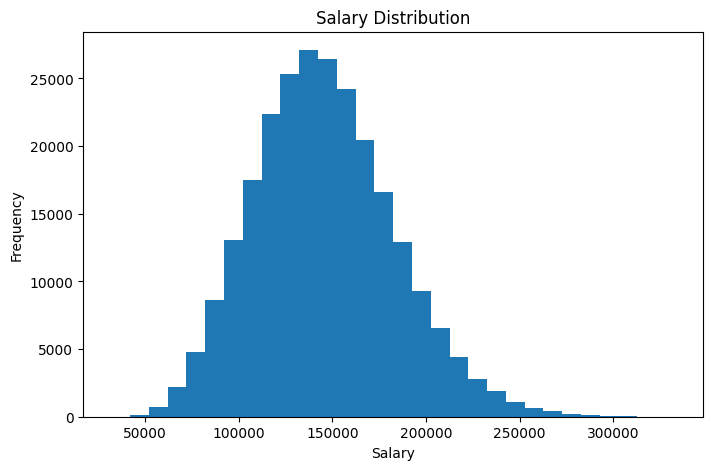

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['salary'], bins=30)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

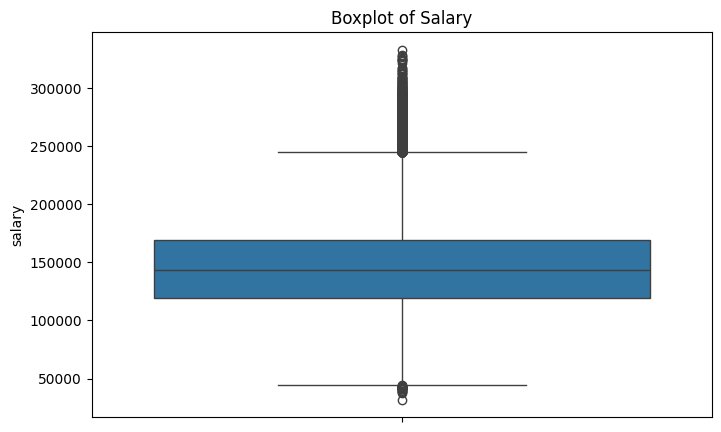

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(y=df['salary'])
plt.title('Boxplot of Salary')
plt.show()

In [ ]:
X = df.drop('salary', axis = 1)
y = df['salary']

print(X.shape)
print(y.shape)

(250000, 9)
(250000,)


In [ ]:
X.select_dtypes(include='object').columns

Index(['job_title', 'education_level', 'industry', 'company_size', 'location',
       'remote_work'],
      dtype='object')

In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

print(X_encoded.shape)

(250000, 42)


In [ ]:
X_encoded.head()

,experience_years,skills_count,certifications,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,job_title_Data Scientist,job_title_DevOps Engineer,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(200000, 42)
(50000, 42)
(200000,)
(50000,)


**train Model #1 (Linear regression)**

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("Linear Regression Training Complete!")

Linear Regression Training Complete!


In [ ]:
y_pred_lr = lr.predict(X_test)

print(y_pred_lr[:5])

[172850.85075644  89234.51820968  63791.55580144 168311.83087157
 117222.93245304]


**Evaluating Model #1(Linear Regression)**

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression MAE:",mae_lr)
print("Linear Regression R2 Score:",r2_lr)

Linear Regression MAE: 5436.0969367518055
Linear Regression R2 Score: 0.963469022844696


**Linear Regression RESULTS- MAE=5436.10, R2=0.9635**

**train Model#2(Decision Tree)**

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

print("Decision tree Training Complete!")

Decision tree Training Complete!


In [ ]:
y_pred_dt = dt.predict(X_test)

**Evaluating Model#2(Decision Tree)**

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae_dt = mean_absolute_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree MAE:", mae_dt)
print("Decision Tree R2 Score:", r2_dt)

Decision Tree MAE: 7983.79149
Decision Tree R2 Score: 0.9213374173437188


**Decision Tree RESULTS- MAE=7983.79, R2=0.9213**

**train Model#3(Random Forest)**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("Random Forest Training Complete!")


Random Forest Training Complete!


**Evaluating Model#3(Random Forest)**

In [ ]:
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score

mae_rf = mean_absolute_error(y_test,y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)
print("Random Forest R2 Score:", r2_rf)


Random Forest MAE: 5693.018592038335
Random Forest R2 Score: 0.9608581821826041


**Random Forest RESULTS- MAE=5693.02, R2=0.9609**

**train Model#4(Gradient Boosting)**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb =GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gb.fit(X_train,y_train)

print("Gradient Boosting Training Complete!")

Gradient Boosting Training Complete!


In [ ]:
y_pred_gb = gb.predict(X_test)

from sklearn.metrics import mean_absolute_error, r2_score

mae_gb = mean_absolute_error(y_test, y_pred_gb)
r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting MAE:", mae_gb)
print("Gradient Boosting R2 Score:", r2_gb)

Gradient Boosting MAE: 8871.415590775072
Gradient Boosting R2 Score: 0.8994272504044918


**Gradient Boosting RESULTS- MAE=8871.42,MAE=0.8994**

**Model Performance Comparison**

**1)Linear Regression**

    MAE: 5436.10
    R² Score: 0.9635

**2)Decision Tree Regressor**

    MAE: 7983.79
    R² Score: 0.9213
**3)Random Forest Regressor**


    MAE: 5693.02
    R² Score: 0.9609
**4)Gradient Boosting Regressor**

    MAE: 8871.42
    R² Score: 0.8994

**Best model:**
*Linear Regression*

In [ ]:
import pandas as pd
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient boosting"
    ],
    "MAE": [
        5436.10,
        7983.79,
        5693.02,
        8871.42
    ],
    "R2 Score": [
        0.9635,
        0.9213,
        0.9609,
        0.8994
    ]

})

results

,Model,MAE,R2 Score
0,Linear Regression,5436.10,0.9635
1,Decision Tree,7983.79,0.9213
2,Random Forest,5693.02,0.9609
3,Gradient boosting,8871.42,0.8994
